# Data Science/ Analytics Intern Assignment

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ribhu\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### 2. Load Data

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

### 3. Basic Checks

In [3]:
print("TRADES SHAPE:", trades.shape)
print("SENTIMENT SHAPE:", sentiment.shape)

print("\nTRADES HEAD:")
print(trades.head())

print("\nSENTIMENT HEAD:")
print(sentiment.head())

print("\nMISSING VALUES - TRADES")
print(trades.isnull().sum())

print("\nMISSING VALUES - SENTIMENT")
print(sentiment.isnull().sum())

print("\nDUPLICATES - TRADES:", trades.duplicated().sum())
print("DUPLICATES - SENTIMENT:", sentiment.duplicated().sum())

TRADES SHAPE: (211224, 16)
SENTIMENT SHAPE: (2644, 4)

TRADES HEAD:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                       

### 4. Convert timestamps and numeric coloumns

In [4]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
trades['Date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['Date'] = sentiment['date'].dt.date

numeric_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Closed PnL', 'Fee']
for col in numeric_cols:
    trades[col] = pd.to_numeric(trades[col], errors='coerce')

print(trades[['Timestamp', 'Date']].head())
print(sentiment[['date', 'Date']].head())

            Timestamp        Date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27
        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


### 5. KEEP RELEVANT SENTIMENT COLUMNS

In [5]:
sentiment = sentiment[['Date', 'classification']].copy()
sentiment['classification'] = sentiment['classification'].astype(str).str.strip().str.title()

print(sentiment.head())
print(sentiment['classification'].value_counts())

         Date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


### 6. CREATE HELPER COLUMNS (BUY = long, SELL = short)

In [6]:
trades['Side'] = trades['Side'].astype(str).str.strip().str.upper()

trades['is_win'] = np.where(trades['Closed PnL'] > 0, 1, 0)
trades['is_loss'] = np.where(trades['Closed PnL'] < 0, 1, 0)

trades['is_long'] = np.where(trades['Side'] == 'BUY', 1, 0)
trades['is_short'] = np.where(trades['Side'] == 'SELL', 1, 0)

print(trades[['Side', 'Closed PnL', 'is_win', 'is_loss', 'is_long', 'is_short']].head())

  Side  Closed PnL  is_win  is_loss  is_long  is_short
0  BUY         0.0       0        0        1         0
1  BUY         0.0       0        0        1         0
2  BUY         0.0       0        0        1         0
3  BUY         0.0       0        0        1         0
4  BUY         0.0       0        0        1         0


### 7. CREATE DAILY METRICS

In [7]:
daily_metrics = trades.groupby('Date').agg(
    daily_pnl=('Closed PnL', 'sum'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    loss_rate=('is_loss', 'mean'),
    avg_trade_size_usd=('Size USD', 'mean'),
    median_trade_size_usd=('Size USD', 'median'),
    total_volume_usd=('Size USD', 'sum'),
    trade_count=('Account', 'count'),
    unique_traders=('Account', 'nunique'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum'),
    avg_fee=('Fee', 'mean')
).reset_index()

daily_metrics['long_short_ratio'] = (
    daily_metrics['long_trades'] / daily_metrics['short_trades'].replace(0, np.nan)
)

print(daily_metrics.head())

         Date     daily_pnl  avg_pnl_per_trade  win_rate  loss_rate  \
0  2023-03-28  0.000000e+00           0.000000  0.000000   0.000000   
1  2023-11-14  1.555034e+02           0.148807  0.274641   0.187560   
2  2024-03-09  1.769655e+05          25.418772  0.490089   0.132146   
3  2024-07-03  1.587424e+05          22.229713  0.317182   0.076600   
4  2024-10-27  3.189461e+06          90.504272  0.451605   0.075963   

   avg_trade_size_usd  median_trade_size_usd  total_volume_usd  trade_count  \
0          159.000000                156.390      4.770000e+02            3   
1        11057.827522               3625.950      1.155543e+07         1045   
2         5660.265764               1148.635      3.940677e+07         6962   
3         3058.848110                554.160      2.184323e+07         7141   
4         2949.625864                498.690      1.039478e+08        35241   

   unique_traders  long_trades  short_trades   avg_fee  long_short_ratio  
0               1      

### 8. MERGE DAILY METRICS WITH SENTIMENT

In [8]:
merged = pd.merge(daily_metrics, sentiment, on='Date', how='inner')

print("MERGED SHAPE:", merged.shape)
print(merged.head())

print("\nCLASSIFICATION COUNTS:")
print(merged['classification'].value_counts())

print("\nDATE RANGE - TRADES:")
print(trades['Date'].min(), "to", trades['Date'].max())

print("\nDATE RANGE - SENTIMENT:")
print(sentiment['Date'].min(), "to", sentiment['Date'].max())

MERGED SHAPE: (6, 15)
         Date     daily_pnl  avg_pnl_per_trade  win_rate  loss_rate  \
0  2023-03-28  0.000000e+00           0.000000  0.000000   0.000000   
1  2023-11-14  1.555034e+02           0.148807  0.274641   0.187560   
2  2024-03-09  1.769655e+05          25.418772  0.490089   0.132146   
3  2024-07-03  1.587424e+05          22.229713  0.317182   0.076600   
4  2024-10-27  3.189461e+06          90.504272  0.451605   0.075963   

   avg_trade_size_usd  median_trade_size_usd  total_volume_usd  trade_count  \
0          159.000000                156.390      4.770000e+02            3   
1        11057.827522               3625.950      1.155543e+07         1045   
2         5660.265764               1148.635      3.940677e+07         6962   
3         3058.848110                554.160      2.184323e+07         7141   
4         2949.625864                498.690      1.039478e+08        35241   

   unique_traders  long_trades  short_trades   avg_fee  long_short_ratio  \


### 9. CREATE BROADER SENTIMENT GROUP

In [9]:

merged['sentiment_group'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed',
    'Neutral': 'Neutral'
})

print(merged['sentiment_group'].value_counts())

sentiment_group
Greed      4
Neutral    1
Fear       1
Name: count, dtype: int64


### 10. FEAR/GREED SUMMARY TABLE

In [10]:
fear_greed_summary = merged.groupby('sentiment_group').agg(
    days=('Date', 'count'),
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean'),
    avg_unique_traders=('unique_traders', 'mean'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    avg_total_volume_usd=('total_volume_usd', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

print(fear_greed_summary)

  sentiment_group  days  avg_daily_pnl  median_daily_pnl  avg_win_rate  \
0            Fear     1   6.699925e+06      6.699925e+06      0.415146   
1           Greed     4   8.416455e+05      8.856050e+04      0.304084   
2         Neutral     1   1.587424e+05      1.587424e+05      0.317182   

   avg_trade_count  avg_unique_traders  avg_trade_size_usd  \
0        133871.00               32.00         5259.977837   
1         10812.75                9.25         4956.679788   
2          7141.00                8.00         3058.848110   

   avg_total_volume_usd  avg_long_short_ratio  
0          7.041585e+08              0.974790  
1          3.872761e+07              0.853277  
2          2.184323e+07              0.963971  


### 11. BAR CHART - AVG DAILY PNL

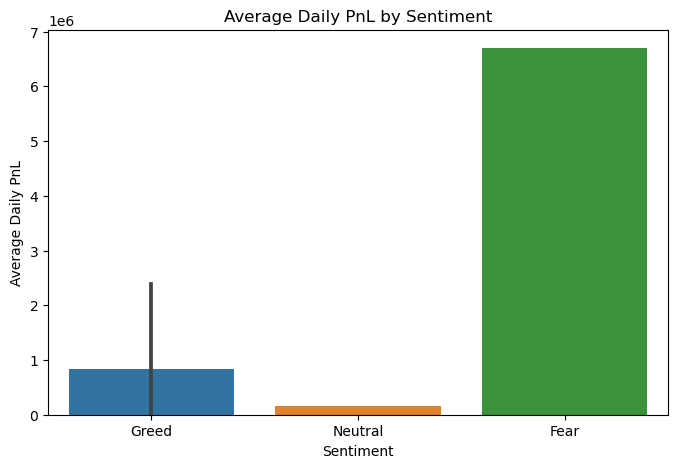

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x='sentiment_group', y='daily_pnl', data=merged, estimator=np.mean)
plt.title("Average Daily PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

### 12. BAR CHART - AVG WIN RATE

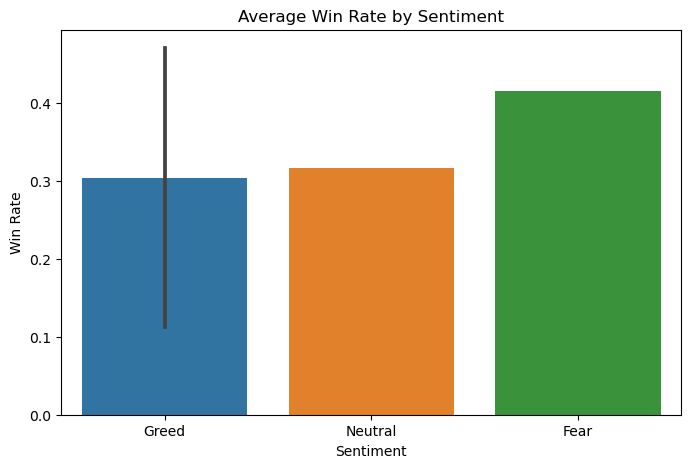

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='sentiment_group', y='win_rate', data=merged, estimator=np.mean)
plt.title("Average Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.show()

### 13. BAR CHART - AVG TRADE COUNT

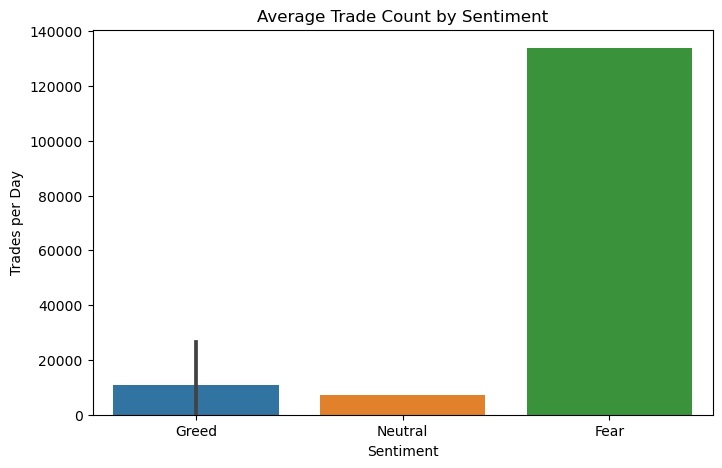

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='sentiment_group', y='trade_count', data=merged, estimator=np.mean)
plt.title("Average Trade Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trades per Day")
plt.show()

### 14. BAR CHART - AVG TRADE SIZE

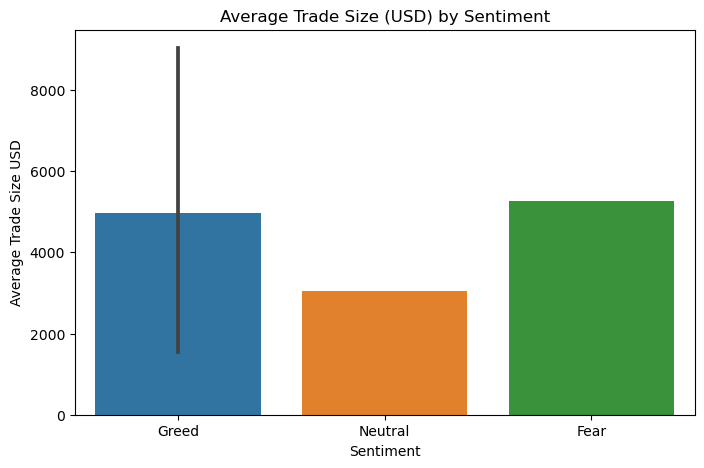

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='sentiment_group', y='avg_trade_size_usd', data=merged, estimator=np.mean)
plt.title("Average Trade Size (USD) by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size USD")
plt.show()

### 15. BOXPLOT - DAILY PNL

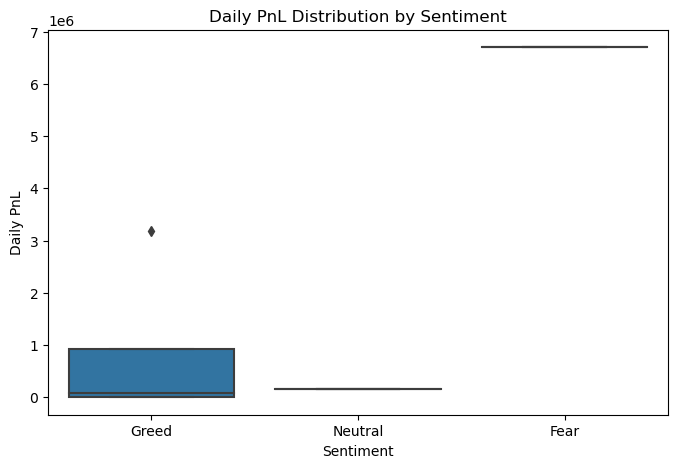

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment_group', y='daily_pnl', data=merged)
plt.title("Daily PnL Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Daily PnL")
plt.show()

### 16. BOXPLOT - LONG/SHORT RATIO

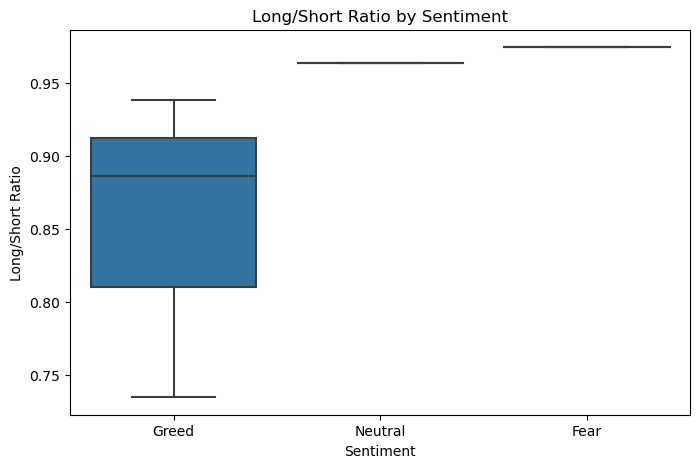

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment_group', y='long_short_ratio', data=merged)
plt.title("Long/Short Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Long/Short Ratio")
plt.show()

### 17. TRADER-LEVEL SUMMARY

In [17]:
trader_summary = trades.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    trade_count=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum')
).reset_index()

trader_summary['long_short_ratio'] = (
    trader_summary['long_trades'] / trader_summary['short_trades'].replace(0, np.nan)
)

print(trader_summary.head())
print(trader_summary.columns)

                                      Account     total_pnl     avg_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04    6.577654   
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04  -18.492043   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05    9.951530   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05   52.071011   

   trade_count  win_rate  avg_trade_size_usd  total_volume_usd  long_trades  \
0         3818  0.359612        16159.576734       61697263.97         1711   
1         7280  0.442720         1653.226327       12035487.66         3055   
2         3809  0.301917         8893.000898       33873440.42         1566   
3        13311  0.438585          507.626933        6757022.10         6699   
4         3239  0.519914         3138.894782       10166880.20         1179   

   short_trades  long_short_ratio  
0          2107          0.812055  
1 

### 18. Segment 1- Frequency Segment

In [18]:
trade_count_median = trader_summary['trade_count'].median()

trader_summary['frequency_segment'] = np.where(
    trader_summary['trade_count'] >= trade_count_median,
    'Frequent',
    'Infrequent'
)

print(trader_summary[['Account', 'trade_count', 'frequency_segment']].head())
print(trader_summary['frequency_segment'].value_counts())

                                      Account  trade_count frequency_segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818          Frequent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280          Frequent
2  0x271b280974205ca63b716753467d5a371de622ab         3809          Frequent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311          Frequent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239        Infrequent
frequency_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64


### 19. SEGMENT 2 - PERFORMANCE SEGMENT

In [19]:
trader_summary['performance_segment'] = np.select(
    [
        (trader_summary['total_pnl'] > 0) & (trader_summary['win_rate'] >= 0.5),
        (trader_summary['total_pnl'] > 0) & (trader_summary['win_rate'] < 0.5)
    ],
    [
        'Consistent Winners',
        'Inconsistent Winners'
    ],
    default='Losing Traders'
)

print(trader_summary[['total_pnl', 'win_rate', 'performance_segment']].head())
print(trader_summary['performance_segment'].value_counts())

      total_pnl  win_rate   performance_segment
0  1.600230e+06  0.359612  Inconsistent Winners
1  4.788532e+04  0.442720  Inconsistent Winners
2 -7.043619e+04  0.301917        Losing Traders
3  1.324648e+05  0.438585  Inconsistent Winners
4  1.686580e+05  0.519914    Consistent Winners
performance_segment
Inconsistent Winners    26
Losing Traders           3
Consistent Winners       3
Name: count, dtype: int64


### 20. SEGMENT 3 - LARGE VS SMALL SIZE

In [20]:
size_median = trader_summary['avg_trade_size_usd'].median()

trader_summary['size_segment'] = np.where(
    trader_summary['avg_trade_size_usd'] >= size_median,
    'Large Size',
    'Small Size'
)

print(trader_summary['size_segment'].value_counts())

print(
    trader_summary.groupby('size_segment')[['total_pnl', 'avg_pnl', 'trade_count', 'win_rate']].mean()
)

size_segment
Large Size    16
Small Size    16
Name: count, dtype: int64
                  total_pnl     avg_pnl  trade_count  win_rate
size_segment                                                  
Large Size    416805.966542  123.839878    4185.3125  0.361684
Small Size    226753.967423   71.532714    9016.1875  0.444441


### 21. SEGMENT CHARTS

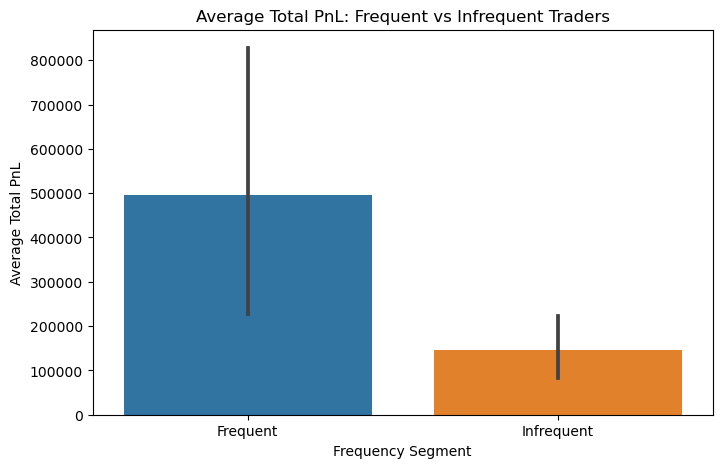

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='frequency_segment', y='total_pnl', data=trader_summary, estimator=np.mean)
plt.title("Average Total PnL: Frequent vs Infrequent Traders")
plt.xlabel("Frequency Segment")
plt.ylabel("Average Total PnL")
plt.show()

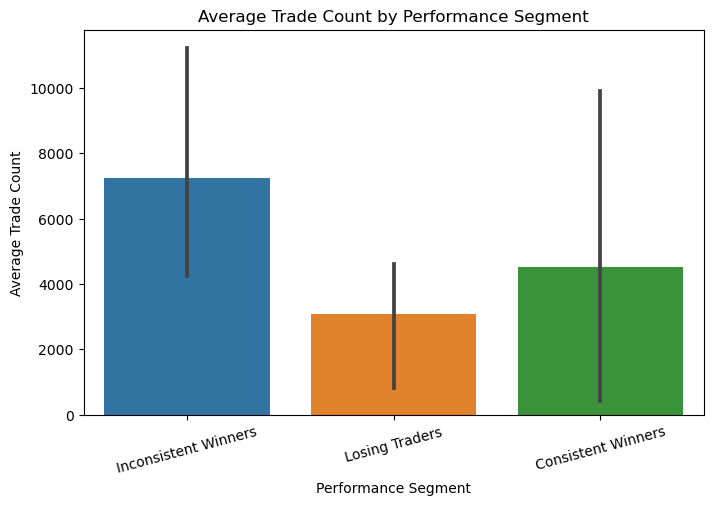

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x='performance_segment', y='trade_count', data=trader_summary, estimator=np.mean)
plt.title("Average Trade Count by Performance Segment")
plt.xlabel("Performance Segment")
plt.ylabel("Average Trade Count")
plt.xticks(rotation=15)
plt.show()

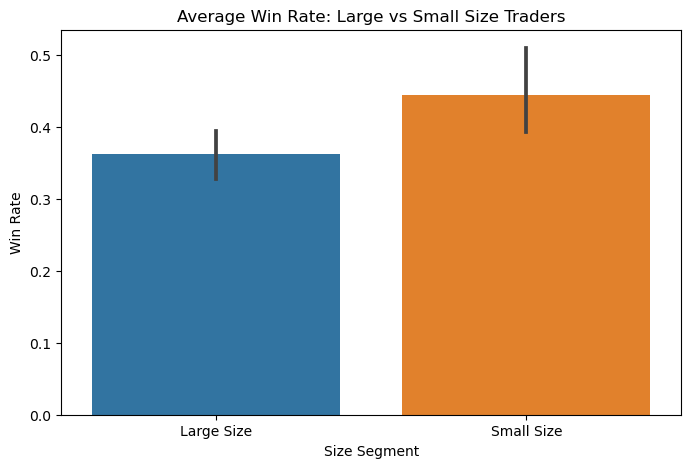

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x='size_segment', y='win_rate', data=trader_summary, estimator=np.mean)
plt.title("Average Win Rate: Large vs Small Size Traders")
plt.xlabel("Size Segment")
plt.ylabel("Win Rate")
plt.show()

### 22. ACCOUNT-DAILY METRICS

In [24]:
account_daily = trades.groupby(['Account', 'Date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size_usd=('Size USD', 'mean'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum')
).reset_index()

account_daily['long_short_ratio'] = (
    account_daily['long_trades'] / account_daily['short_trades'].replace(0, np.nan)
)

account_daily = pd.merge(account_daily, sentiment, on='Date', how='inner')
account_daily['sentiment_group'] = account_daily['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed',
    'Neutral': 'Neutral'
})

print(account_daily.head())

                                      Account        Date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   

   trade_count  win_rate  avg_trade_size_usd  long_trades  short_trades  \
0          462  0.025974        14810.891818          139           323   
1         3356  0.405542        16345.241940         1572          1784   
2          320  0.531250         2492.749906          145           175   
3         3533  0.435041         1693.351684         1528          2005   
4            5  0.000000         6070.200000            2             3   

   long_short_ratio classification sentiment_group  
0          0.430341          Greed           

### 23. ACCOUNT-LEVEL SENTIMENT IMPACT

In [25]:
print(
    account_daily.groupby('sentiment_group')[['daily_pnl', 'trade_count', 'win_rate', 'avg_trade_size_usd', 'long_short_ratio']].mean()
)

                     daily_pnl  trade_count  win_rate  avg_trade_size_usd  \
sentiment_group                                                             
Fear             209372.662205  4183.468750  0.415878         5926.522723   
Greed             90988.703436  1168.945946  0.369012         5637.302441   
Neutral           19842.797260   892.625000  0.260683         3793.444161   

                 long_short_ratio  
sentiment_group                    
Fear                     0.968130  
Greed                    1.222797  
Neutral                  1.243288  


### 24. EXTRA CHARTS

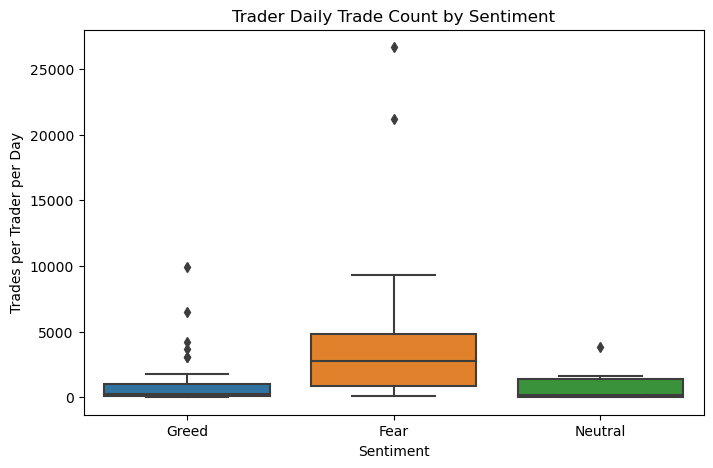

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment_group', y='trade_count', data=account_daily)
plt.title("Trader Daily Trade Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trades per Trader per Day")
plt.show()

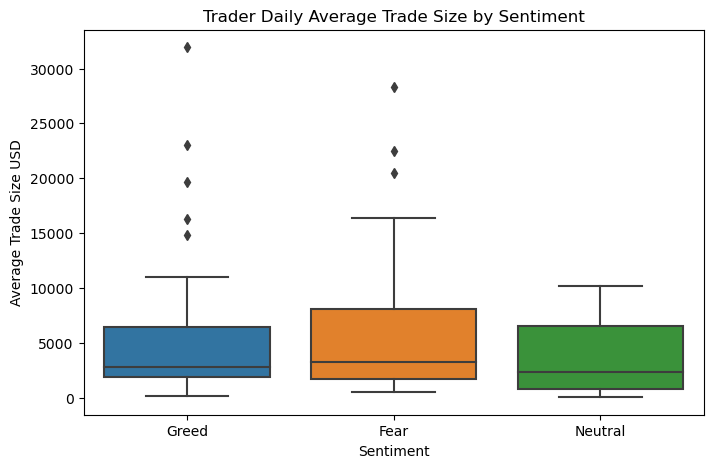

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment_group', y='avg_trade_size_usd', data=account_daily)
plt.title("Trader Daily Average Trade Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size USD")
plt.show()

### 25. Drawdown Proxy

In [28]:
merged['loss_day_flag'] = np.where(merged['daily_pnl'] < 0, 1, 0)

drawdown_proxy = merged.groupby('sentiment_group').agg(
    pct_loss_days=('loss_day_flag', 'mean'),
    avg_negative_pnl=('daily_pnl', lambda x: x[x < 0].mean())
).reset_index()

print(drawdown_proxy)

  sentiment_group  pct_loss_days  avg_negative_pnl
0            Fear            0.0               NaN
1           Greed            0.0               NaN
2         Neutral            0.0               NaN


## Final Outputs

In [29]:
fear_greed_summary.to_csv("fear_greed_summary.csv", index=False)
trader_summary.to_csv("trader_summary.csv", index=False)
merged.to_csv("merged_daily_metrics.csv", index=False)
account_daily.to_csv("account_daily_metrics.csv", index=False)
drawdown_proxy.to_csv("drawdown_proxy.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.


In [30]:
print(fear_greed_summary)
print(drawdown_proxy)
print(trader_summary.head())

  sentiment_group  days  avg_daily_pnl  median_daily_pnl  avg_win_rate  \
0            Fear     1   6.699925e+06      6.699925e+06      0.415146   
1           Greed     4   8.416455e+05      8.856050e+04      0.304084   
2         Neutral     1   1.587424e+05      1.587424e+05      0.317182   

   avg_trade_count  avg_unique_traders  avg_trade_size_usd  \
0        133871.00               32.00         5259.977837   
1         10812.75                9.25         4956.679788   
2          7141.00                8.00         3058.848110   

   avg_total_volume_usd  avg_long_short_ratio  
0          7.041585e+08              0.974790  
1          3.872761e+07              0.853277  
2          2.184323e+07              0.963971  
  sentiment_group  pct_loss_days  avg_negative_pnl
0            Fear            0.0               NaN
1           Greed            0.0               NaN
2         Neutral            0.0               NaN
                                      Account     total_pn